<a href="https://colab.research.google.com/github/NSF-DARSE/YolktoFeed/blob/main/JupyterNotebook/liverHEDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Checks to the implemented
- Test is the all values from column 1 df.iloc[:,1:] to the right is numbers
- Test if column name follows the same pattern
- While omitting based on average, see if any value has any spike on some days

In [3]:
import pandas as pd
import sys

In [4]:
#from google.colab import drive
#drive.mount("/content/drive/")

In [5]:
path = "/content/drive/Shareddrives/NSF-SCIPE-DARSE/Research Software Engineers (RSE)/Abhin/Projects/Carl Schmidt"
sys.path.append(path)

In [9]:
df_base = pd.read_csv(path+"/Liver_HEIDI_complete_ensembl_symbol.csv")

### Things to add as infomation: number of dats in each day, like day 4 has 12 columns

In [10]:
print("Number of genes: ", df_base.shape[0])

# finding last row with valid gene symbol
gene_list_last_index = (df_base["Gene Symbol"] == "-").idxmax()

print("Number of nan's: ", df_base.iloc[:,2:].apply(pd.to_numeric, errors='coerce').isna().sum().sum())

Number of genes:  24869
Number of nan's:  0


## Trucating till the valid gene name

In [11]:
#truncating till that row
df_trunk = df_base.iloc[:gene_list_last_index]
df_trunk = df_trunk.drop(columns=["Ensembl Gene ID"])
df_trunk = df_trunk.set_index("Gene Symbol")
df_trunk

,1650_summed_TPM_4,1651_summed_TPM_4,1653_summed_TPM_4,1654_summed_TPM_4,1655_summed_TPM_4,1656_summed_TPM_4,1657_summed_TPM_4,1671_summed_TPM_4,1672_summed_TPM_4,1673_summed_TPM_4,...,1735_summed_TPM_20,1736_summed_TPM_20,1742_summed_TPM_20,1743_summed_TPM_20,1744_summed_TPM_20,1745_summed_TPM_20,1746_summed_TPM_20,1747_summed_TPM_20,1748_summed_TPM_20,1749_summed_TPM_20
Gene Symbol,,,,,,,,,,,,,,,,,,,,,
ZZZ3,2.148670,4.204060,3.609380,6.677230,3.849120,7.354150,5.040800,3.031530,2.721210,3.941250,...,0.970587,1.66351,1.636580,2.459220,4.893390,2.489600,3.19717,1.468440,2.091560,0.187683
ZYX,24.366200,32.569200,31.253900,37.847200,37.692800,56.604800,33.385700,27.918300,34.052300,57.311000,...,13.140900,24.40290,25.381200,28.666700,34.741500,22.507700,29.35630,25.152600,34.865400,12.079700
ZXDC,2.032480,2.471470,1.543100,3.037720,1.771860,4.079810,2.900180,2.161720,2.230180,4.596810,...,0.945374,1.22140,1.271560,2.263090,2.274030,1.651320,2.59244,2.715000,2.818080,0.710741
ZW10,4.834760,7.150830,5.563670,10.117100,5.905610,12.052000,9.869820,6.426870,5.543910,8.634280,...,2.026740,3.13406,4.484710,5.776710,8.311750,4.391920,6.41727,4.316070,5.518810,1.944010
ZUFSP,3.170700,2.908370,2.354820,3.346660,2.564770,3.133150,4.454180,3.496990,2.421560,2.140630,...,2.675900,1.74104,1.222440,3.358820,3.351070,2.998520,2.41147,1.658470,2.003540,0.645755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A4GALT,0.074452,0.156464,0.029587,0.139465,0.190539,0.308782,0.056601,0.067055,0.061017,0.105077,...,0.172556,0.00000,0.131267,0.230045,0.594857,0.254973,0.22188,0.201177,0.596807,0.095215
A2ML4,243.909000,340.262000,289.809000,584.728000,281.682000,509.980000,664.186000,492.456000,1092.230000,723.640000,...,211.638000,641.81200,604.835000,1026.430000,1004.110000,480.376000,1000.24000,778.891000,1191.370000,394.840000
A2ML2,247.332000,182.951000,172.501000,183.129000,118.826000,234.194000,283.293000,169.966000,165.030000,182.840000,...,130.653000,193.07000,301.891000,275.247000,395.356000,316.083000,156.38600,128.938000,186.548000,81.135700


## Adding a column for average and variance value of gene expression

In [12]:
# Adding a column for average gene expression across all days and all chikens for prelim analysis
df_trunk.insert(0, "avg", df_trunk.iloc[:, 1:].sum(axis=1)/(df_trunk.shape[1]-1))
df_trunk.insert(1, "sigma", df_trunk.iloc[:,1:].var(axis=1))
df_trunk.insert(2, "max", df_trunk.iloc[:,1:].max(axis=1))

In [13]:
df_trunk

,avg,sigma,max,1650_summed_TPM_4,1651_summed_TPM_4,1653_summed_TPM_4,1654_summed_TPM_4,1655_summed_TPM_4,1656_summed_TPM_4,1657_summed_TPM_4,...,1735_summed_TPM_20,1736_summed_TPM_20,1742_summed_TPM_20,1743_summed_TPM_20,1744_summed_TPM_20,1745_summed_TPM_20,1746_summed_TPM_20,1747_summed_TPM_20,1748_summed_TPM_20,1749_summed_TPM_20
Gene Symbol,,,,,,,,,,,,,,,,,,,,,
ZZZ3,3.636232,4.117117,10.133400,2.148670,4.204060,3.609380,6.677230,3.849120,7.354150,5.040800,...,0.970587,1.66351,1.636580,2.459220,4.893390,2.489600,3.19717,1.468440,2.091560,0.187683
ZYX,29.023858,92.913630,92.913630,24.366200,32.569200,31.253900,37.847200,37.692800,56.604800,33.385700,...,13.140900,24.40290,25.381200,28.666700,34.741500,22.507700,29.35630,25.152600,34.865400,12.079700
ZXDC,2.309251,1.170901,5.924810,2.032480,2.471470,1.543100,3.037720,1.771860,4.079810,2.900180,...,0.945374,1.22140,1.271560,2.263090,2.274030,1.651320,2.59244,2.715000,2.818080,0.710741
ZW10,6.465182,8.904335,14.179500,4.834760,7.150830,5.563670,10.117100,5.905610,12.052000,9.869820,...,2.026740,3.13406,4.484710,5.776710,8.311750,4.391920,6.41727,4.316070,5.518810,1.944010
ZUFSP,3.951590,5.661528,12.019500,3.170700,2.908370,2.354820,3.346660,2.564770,3.133150,4.454180,...,2.675900,1.74104,1.222440,3.358820,3.351070,2.998520,2.41147,1.658470,2.003540,0.645755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A4GALT,0.297582,0.036969,0.882417,0.074452,0.156464,0.029587,0.139465,0.190539,0.308782,0.056601,...,0.172556,0.00000,0.131267,0.230045,0.594857,0.254973,0.22188,0.201177,0.596807,0.095215
A2ML4,667.621728,152112.494262,152112.494262,243.909000,340.262000,289.809000,584.728000,281.682000,509.980000,664.186000,...,211.638000,641.81200,604.835000,1026.430000,1004.110000,480.376000,1000.24000,778.891000,1191.370000,394.840000
A2ML2,210.377168,8639.069259,8639.069259,247.332000,182.951000,172.501000,183.129000,118.826000,234.194000,283.293000,...,130.653000,193.07000,301.891000,275.247000,395.356000,316.083000,156.38600,128.938000,186.548000,81.135700


## Part before omission of valid rows

In [14]:
df = df_trunk

In [15]:
#Basic stats on average gene expression levels with their corresponding sigma
#column 0 is avg, 1 is sigma, 2 is max
ind = 0
print("number of Genes and max-variance, avg less than 1e-6 and its max sigma/val:\t", df.loc[df.iloc[:,ind] < 1e-6, df.columns[0:2]].shape[0], "\t",  df.loc[df.iloc[:,ind] < 1e-6, df.columns[2]].max(), "\t", df.loc[df.iloc[:,ind] < 1e-6, df.columns[3]].max())
print("number of Genes and max-variance, avg less than 1e-4 and its max sigma/val:\t", df.loc[df.iloc[:,ind] < 1e-4, df.columns[0:2]].shape[0], "\t",  df.loc[df.iloc[:,ind] < 1e-4, df.columns[2]].max(), "\t", df.loc[df.iloc[:,ind] < 1e-4, df.columns[3]].max())
print("number of Genes and max-variance, avg less than 1e-2 and its max sigma/val:\t", df.loc[df.iloc[:,ind] < 1e-2, df.columns[0:2]].shape[0], "\t",  df.loc[df.iloc[:,ind] < 1e-2, df.columns[2]].max(), "\t", df.loc[df.iloc[:,ind] < 1e-2, df.columns[3]].max())
print("number of Genes and max-variance, avg less than 1e-1 and its max sigma/val:\t", df.loc[df.iloc[:,ind] < 1e-1, df.columns[0:2]].shape[0], "\t",  df.loc[df.iloc[:,ind] < 1e-1, df.columns[2]].max(), "\t", df.loc[df.iloc[:,ind] < 1e-1, df.columns[3]].max())

number of Genes and max-variance, avg less than 1e-6 and its max sigma/val:	 861 	 0.206353 	 0.206353
number of Genes and max-variance, avg less than 1e-4 and its max sigma/val:	 866 	 0.206353 	 0.206353
number of Genes and max-variance, avg less than 1e-2 and its max sigma/val:	 2019 	 1.12591 	 1.12591
number of Genes and max-variance, avg less than 1e-1 and its max sigma/val:	 3234 	 6.5941 	 2.45912


### Printing out whats being omitted

In [16]:
df.loc[(df.loc[:,'avg'] < 1e-1) & (df.loc[:,'max'] > 5), df.columns[:3]]
#df.loc[df.iloc[:,ind] < 1e-2, df.columns[0:2]]

,avg,sigma,max
Gene Symbol,,,
NPY,0.080413,0.429176,6.59410
FGF13,0.063062,0.298024,5.59578


## Keeping genes with avg > 0.1

In [17]:
#df = df[(df.loc[:,'avg'] > 1e-1) | (df.loc[:,'max'] > 1)]
df = df[(df.loc[:,'avg'] > 1e-1)]
display(df)
print("Number of genes left: ", df.shape[0])

,avg,sigma,max,1650_summed_TPM_4,1651_summed_TPM_4,1653_summed_TPM_4,1654_summed_TPM_4,1655_summed_TPM_4,1656_summed_TPM_4,1657_summed_TPM_4,...,1735_summed_TPM_20,1736_summed_TPM_20,1742_summed_TPM_20,1743_summed_TPM_20,1744_summed_TPM_20,1745_summed_TPM_20,1746_summed_TPM_20,1747_summed_TPM_20,1748_summed_TPM_20,1749_summed_TPM_20
Gene Symbol,,,,,,,,,,,,,,,,,,,,,
ZZZ3,3.636232,4.117117,10.133400,2.148670,4.204060,3.609380,6.677230,3.849120,7.354150,5.040800,...,0.970587,1.66351,1.636580,2.459220,4.893390,2.489600,3.19717,1.468440,2.091560,0.187683
ZYX,29.023858,92.913630,92.913630,24.366200,32.569200,31.253900,37.847200,37.692800,56.604800,33.385700,...,13.140900,24.40290,25.381200,28.666700,34.741500,22.507700,29.35630,25.152600,34.865400,12.079700
ZXDC,2.309251,1.170901,5.924810,2.032480,2.471470,1.543100,3.037720,1.771860,4.079810,2.900180,...,0.945374,1.22140,1.271560,2.263090,2.274030,1.651320,2.59244,2.715000,2.818080,0.710741
ZW10,6.465182,8.904335,14.179500,4.834760,7.150830,5.563670,10.117100,5.905610,12.052000,9.869820,...,2.026740,3.13406,4.484710,5.776710,8.311750,4.391920,6.41727,4.316070,5.518810,1.944010
ZUFSP,3.951590,5.661528,12.019500,3.170700,2.908370,2.354820,3.346660,2.564770,3.133150,4.454180,...,2.675900,1.74104,1.222440,3.358820,3.351070,2.998520,2.41147,1.658470,2.003540,0.645755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A4GALT,0.297582,0.036969,0.882417,0.074452,0.156464,0.029587,0.139465,0.190539,0.308782,0.056601,...,0.172556,0.00000,0.131267,0.230045,0.594857,0.254973,0.22188,0.201177,0.596807,0.095215
A2ML4,667.621728,152112.494262,152112.494262,243.909000,340.262000,289.809000,584.728000,281.682000,509.980000,664.186000,...,211.638000,641.81200,604.835000,1026.430000,1004.110000,480.376000,1000.24000,778.891000,1191.370000,394.840000
A2ML2,210.377168,8639.069259,8639.069259,247.332000,182.951000,172.501000,183.129000,118.826000,234.194000,283.293000,...,130.653000,193.07000,301.891000,275.247000,395.356000,316.083000,156.38600,128.938000,186.548000,81.135700


Number of genes left:  11231


In [18]:
ind = 1
print("number of Genes with variance less than 1e-6:\t", df.loc[df.iloc[:,ind] < 1e-6, :].shape[0], "\t", df.loc[df.iloc[:,ind] < 1e-6, df.columns[3]].max())
print("number of Genes with variance less than 1e-4:\t", df.loc[df.iloc[:,ind] < 1e-4, :].shape[0], "\t", df.loc[df.iloc[:,ind] < 1e-4, df.columns[3]].max())
print("number of Genes with variance less than 1e-2:\t", df.loc[df.iloc[:,ind] < 1e-2, :].shape[0], "\t", df.loc[df.iloc[:,ind] < 1e-2, df.columns[3]].max())
print("number of Genes with variance less than 1e-1:\t", df.loc[df.iloc[:,ind] < 1e-1, :].shape[0], "\t", df.loc[df.iloc[:,ind] < 1e-1, df.columns[3]].max())

number of Genes with variance less than 1e-6:	 0 	 nan
number of Genes with variance less than 1e-4:	 0 	 nan
number of Genes with variance less than 1e-2:	 18 	 0.331093
number of Genes with variance less than 1e-1:	 716 	 2.08219


## Keeping genes with sigma > 0.1

In [19]:
df = df[(df.loc[:,'sigma'] > 1e-1)]
print("Number of genes left: ", df.shape[0])

Number of genes left:  10515


## Some metrics of the final database

In [20]:
print("Minimum of the avg values", df.loc[:,'avg'].min(),)
print("Minimum sigma values", df.loc[:,'sigma'].min())
#display(df.loc[df.loc[:,'sigma'] < 0.01, df.columns[:4]])


Minimum of the avg values 0.1020289619047619
Minimum sigma values 0.10008783065491977


In [ ]:
df.to_csv('filterd_LIVER_HEIDI.csv')

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## PCA Analysis on the transcriptome data
## Constructing metadata, expression, log-expression dataframe

In [34]:
#DAYS = [4, 6, 8, 10, 12, 14, 16, 18, 20]
meta_cols = ['avg', 'sigma', 'max']
expr_cols = [c for c in df.columns if c not in meta_cols]

sample_meta = pd.DataFrame({'Sample': expr_cols})
sample_meta['Day'] = sample_meta['Sample'].str.extract(r'_(\d+)$').astype(int)

display(sample_meta.head())

expr = df[expr_cols].copy()
expr.index = df.index
display(expr.head())

log_expr_val = np.log2(expr.values + 1)
log_expr = pd.DataFrame(log_expr_val, index=expr.index, columns=expr.columns)
display(log_expr.head())

DAYS = sorted(sample_meta['Day'].unique().tolist())
print(DAYS)

,Sample,Day
0,1650_summed_TPM_4,4
1,1651_summed_TPM_4,4
2,1653_summed_TPM_4,4
3,1654_summed_TPM_4,4
4,1655_summed_TPM_4,4


,1650_summed_TPM_4,1651_summed_TPM_4,1653_summed_TPM_4,1654_summed_TPM_4,1655_summed_TPM_4,1656_summed_TPM_4,1657_summed_TPM_4,1671_summed_TPM_4,1672_summed_TPM_4,1673_summed_TPM_4,...,1735_summed_TPM_20,1736_summed_TPM_20,1742_summed_TPM_20,1743_summed_TPM_20,1744_summed_TPM_20,1745_summed_TPM_20,1746_summed_TPM_20,1747_summed_TPM_20,1748_summed_TPM_20,1749_summed_TPM_20
Gene Symbol,,,,,,,,,,,,,,,,,,,,,
ZZZ3,2.14867,4.20406,3.60938,6.67723,3.84912,7.35415,5.04080,3.03153,2.72121,3.94125,...,0.970587,1.66351,1.63658,2.45922,4.89339,2.48960,3.19717,1.46844,2.09156,0.187683
ZYX,24.36620,32.56920,31.25390,37.84720,37.69280,56.60480,33.38570,27.91830,34.05230,57.31100,...,13.140900,24.40290,25.38120,28.66670,34.74150,22.50770,29.35630,25.15260,34.86540,12.079700
ZXDC,2.03248,2.47147,1.54310,3.03772,1.77186,4.07981,2.90018,2.16172,2.23018,4.59681,...,0.945374,1.22140,1.27156,2.26309,2.27403,1.65132,2.59244,2.71500,2.81808,0.710741
ZW10,4.83476,7.15083,5.56367,10.11710,5.90561,12.05200,9.86982,6.42687,5.54391,8.63428,...,2.026740,3.13406,4.48471,5.77671,8.31175,4.39192,6.41727,4.31607,5.51881,1.944010
ZUFSP,3.17070,2.90837,2.35482,3.34666,2.56477,3.13315,4.45418,3.49699,2.42156,2.14063,...,2.675900,1.74104,1.22244,3.35882,3.35107,2.99852,2.41147,1.65847,2.00354,0.645755


,1650_summed_TPM_4,1651_summed_TPM_4,1653_summed_TPM_4,1654_summed_TPM_4,1655_summed_TPM_4,1656_summed_TPM_4,1657_summed_TPM_4,1671_summed_TPM_4,1672_summed_TPM_4,1673_summed_TPM_4,...,1735_summed_TPM_20,1736_summed_TPM_20,1742_summed_TPM_20,1743_summed_TPM_20,1744_summed_TPM_20,1745_summed_TPM_20,1746_summed_TPM_20,1747_summed_TPM_20,1748_summed_TPM_20,1749_summed_TPM_20
Gene Symbol,,,,,,,,,,,,,,,,,,,,,
ZZZ3,1.654743,2.379638,2.204573,2.940586,2.277723,3.062493,2.594740,2.011327,1.895772,2.304876,...,0.978625,1.413329,1.398668,1.790447,2.559098,1.803062,2.069417,1.303600,1.628335,0.248150
ZYX,4.664836,5.069066,5.011402,5.279739,5.273993,5.848117,5.103737,4.853911,5.131437,5.865696,...,3.821802,4.666921,4.721438,4.890773,5.159528,4.555061,4.923924,4.708882,5.164521,3.709258
ZXDC,1.600498,1.795547,1.346588,2.013541,1.470854,2.344775,1.963541,1.660710,1.691615,2.484605,...,0.960048,1.151469,1.183683,1.706239,1.711068,1.406711,1.844964,1.893362,1.932847,0.774621
ZW10,2.544673,3.026947,2.714503,3.474709,2.787769,3.706199,3.442256,2.892754,2.710153,3.268177,...,1.597765,2.047559,2.455415,2.760585,3.219052,2.430799,2.890888,2.410360,2.704609,1.557783
ZUFSP,2.060290,1.966567,1.746235,2.119907,1.833809,2.047242,2.447362,2.168960,1.774654,1.651054,...,1.878098,1.454723,1.152144,2.123938,2.121370,1.999466,1.770394,1.410596,1.586664,0.718750


[4, 6, 8, 10, 12, 14, 16, 18, 20]


### Print counter for days

In [23]:
from collections import Counter
Counter(sample_meta['Day'].tolist())

Counter({4: 11, 6: 12, 8: 12, 10: 12, 12: 12, 14: 11, 16: 12, 18: 12, 20: 12})

## Standard scarling, setting mean to zero and variance to 1

### pca_t find the PCA components
### Xpca is the data represeted in the new PCA coordinates system

In [35]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_t        = log_expr.T.values.astype(float)
X_t_scaled = StandardScaler().fit_transform(X_t)

pca_t = PCA(n_components=10, random_state=42)
Xpca  = pca_t.fit_transform(X_t_scaled)

print(f"  PC1 explains: {pca_t.explained_variance_ratio_[0]*100:.1f}% of variance")
print(f"  PC2 explains: {pca_t.explained_variance_ratio_[1]*100:.1f}% of variance")
print(f"  PC3 explains: {pca_t.explained_variance_ratio_[2]*100:.1f}% of variance")
print(f"  PC4 explains: {pca_t.explained_variance_ratio_[3]*100:.1f}% of variance")
print(f"  Xpca shape  : {Xpca.shape}")

  PC1 explains: 55.6% of variance
  PC2 explains: 6.9% of variance
  PC3 explains: 4.2% of variance
  PC4 explains: 3.3% of variance
  Xpca shape  : (106, 10)


In [25]:
DAYS

[4, 6, 8, 10, 12, 14, 16, 18, 20]

In [26]:
DAY_COLORS = {
    4:  '#2ecc71',   # green
    6:  '#27ae60',   # dark green
    8:  '#f1c40f',   # yellow
    10: '#e67e22',   # orange
    12: '#e74c3c',   # red
    14: '#8e44ad',   # PURPLE ← Day 14
    16: '#3498db',   # blue
    18: '#1abc9c',   # teal
    20: '#2c3e50',   # dark navy
}

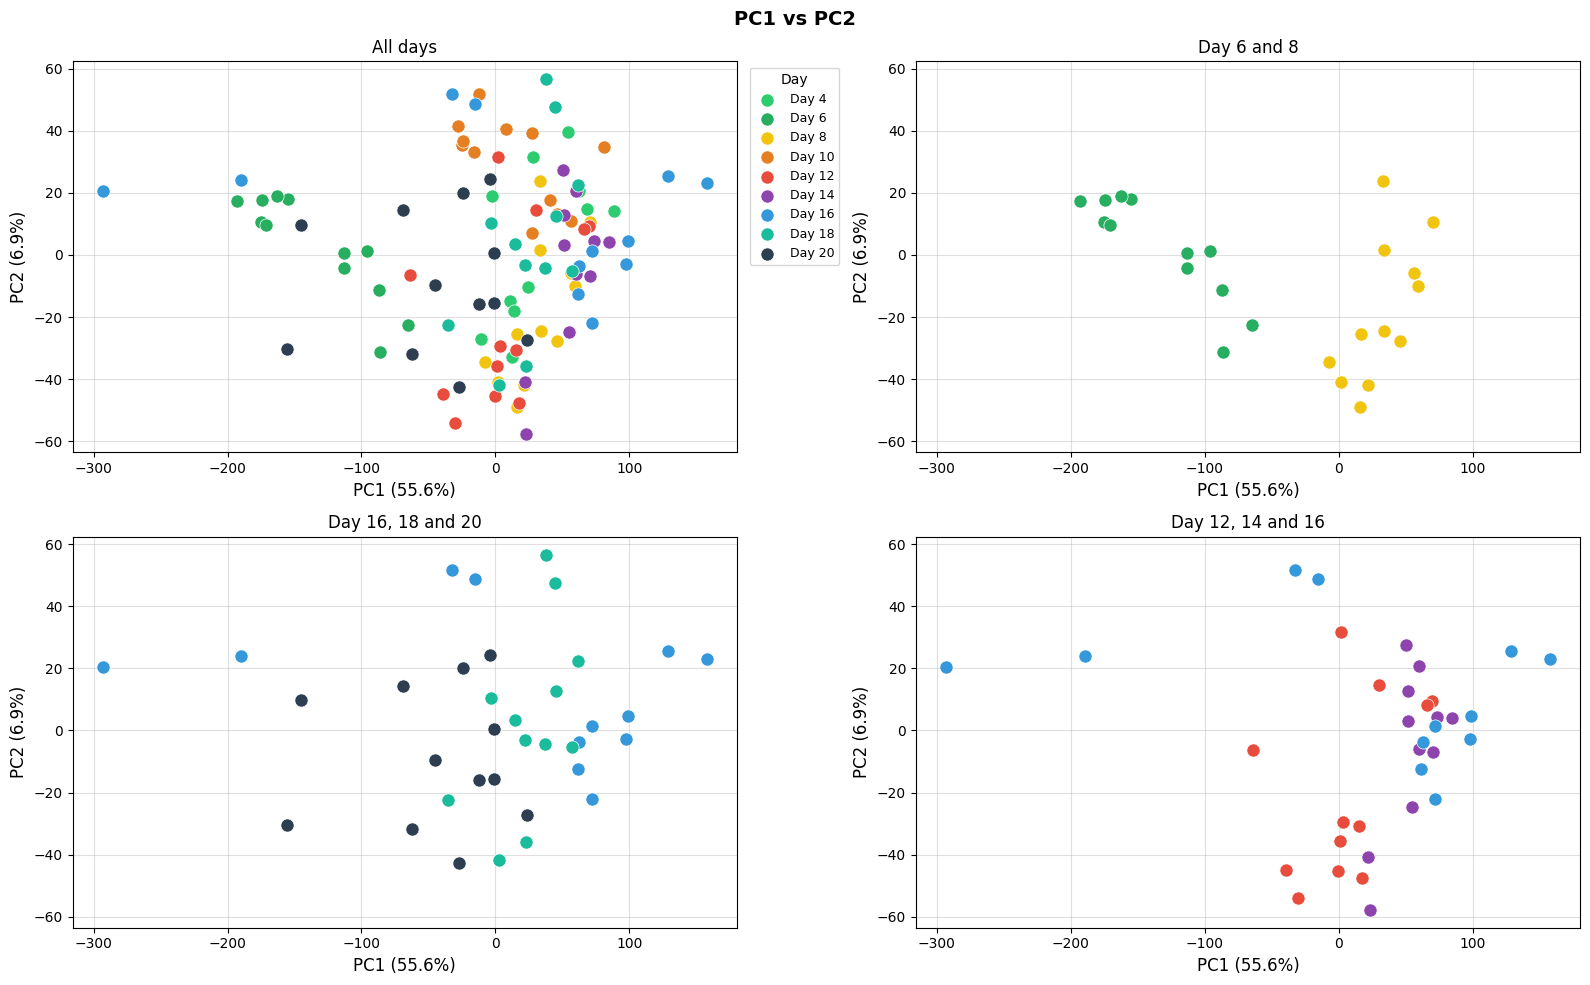

In [33]:
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('PC1 vs PC2',
             fontsize=14, fontweight='bold')
ax1 = axes[0,0]
for day in DAYS:
    idx = np.where(sample_meta['Day'].values == day)[0]
    ax1.scatter(Xpca[idx, 0], Xpca[idx, 1],
               c=DAY_COLORS[day], label=f'Day {day}',
               s=90, edgecolors='white', linewidth=0.5, zorder=3)

d14_idx = np.where(sample_meta['Day'].values == 14)[0]
ax1.set_xlabel(f'PC1 ({pca_t.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax1.set_ylabel(f'PC2 ({pca_t.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax1.set_title('All days', fontsize=12)
ax1.legend(title='Day', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.4)

ax2 = axes[0,1]
for day in [6, 8]:
    idx = np.where(sample_meta['Day'].values == day)[0]
    ax2.scatter(Xpca[idx, 0], Xpca[idx, 1],
               c=DAY_COLORS[day], label=f'Day {day}',
               s=90, edgecolors='white', linewidth=0.5, zorder=3)

    ax2.set_xlim(ax1.get_xlim())
    ax2.set_ylim(ax1.get_ylim())
ax2.set_title('Day 6 and 8', fontsize=12)
ax2.set_xlabel(f'PC1 ({pca_t.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax2.set_ylabel(f'PC2 ({pca_t.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax2.grid(True, alpha=0.4)

ax3 = axes[1,0]
for day in [16, 18, 20]:
    idx = np.where(sample_meta['Day'].values == day)[0]
    ax3.scatter(Xpca[idx, 0], Xpca[idx, 1],
               c=DAY_COLORS[day], label=f'Day {day}',
               s=90, edgecolors='white', linewidth=0.5, zorder=3)

    ax3.set_xlim(ax1.get_xlim())
    ax3.set_ylim(ax1.get_ylim())
ax3.set_title('Day 16, 18 and 20', fontsize=12)
ax3.set_xlabel(f'PC1 ({pca_t.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax3.set_ylabel(f'PC2 ({pca_t.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax3.grid(True, alpha=0.4)

ax4 = axes[1,1]
for day in [12, 14, 16]:
    idx = np.where(sample_meta['Day'].values == day)[0]
    ax4.scatter(Xpca[idx, 0], Xpca[idx, 1],
               c=DAY_COLORS[day], label=f'Day {day}',
               s=90, edgecolors='white', linewidth=0.5, zorder=3)

    ax4.set_xlim(ax1.get_xlim())
    ax4.set_ylim(ax1.get_ylim())
ax4.set_title('Day 12, 14 and 16', fontsize=12)
ax4.set_xlabel(f'PC1 ({pca_t.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax4.set_ylabel(f'PC2 ({pca_t.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax4.grid(True, alpha=0.4)

plt.tight_layout()

#cx, cy  = Xpca[d14_idx, 0].mean(), Xpca[d14_idx, 1].mean()
#circle  = plt.Circle((cx, cy), 3, fill=False, color='#8e44ad',
#                     linewidth=2.5, linestyle='--')
#ax.add_patch(circle)
#ax.annotate('Day 14', (cx, cy), ha='center', fontsize=10,
#            color='#8e44ad', fontweight='bold')


# Differential expression

## Performs Welch’s t-test to test whether the group means differ significantly.

In [36]:
from scipy import stats

print("Computing Day 14 differential expression...")
d14_samples   = sample_meta[sample_meta['Day'] == 14]['Sample'].tolist()
rest_samples = sample_meta[sample_meta['Day'] != 14]['Sample'].tolist()

neighbors_samples = sample_meta[sample_meta['Day'].isin([12,16])]['Sample'].tolist()
before_samples = sample_meta[sample_meta['Day'].isin([4,6])]['Sample'].tolist()
after_samples = sample_meta[sample_meta['Day'].isin([18,20])]['Sample'].tolist()

d14_mean   = log_expr[d14_samples].mean(axis=1)
rest_mean = log_expr[rest_samples].mean(axis=1)

neighbors_mean = log_expr[neighbors_samples].mean(axis=1)
before_mean = log_expr[before_samples].mean(axis=1)
after_mean = log_expr[after_samples].mean(axis=1)

lfc_rest        = d14_mean - rest_mean

prest_vals = []
for g in log_expr.index:
    a = log_expr.loc[g, d14_samples].values.astype(float)
    b = log_expr.loc[g, rest_samples].values.astype(float)
    try:
        _, p = stats.ttest_ind(a, b, equal_var=False)
    except:
        p = 1.0
    prest_vals.append(p)

de_df = pd.DataFrame({'Gene': log_expr.index, 'LFC': lfc_rest.values, 'pval': prest_vals})
de_df['-log10p'] = -np.log10(np.clip(de_df['pval'], 1e-300, 1))
de_df['sig']     = (de_df['pval'] < 0.05) & (de_df['LFC'].abs() > 1)
up = de_df[de_df['sig'] & (de_df['LFC'] > 0)]
dn = de_df[de_df['sig'] & (de_df['LFC'] < 0)]

print(f"  Upregulated at Day 14  : {len(up)} genes")
print(f"  Downregulated at Day 14: {len(dn)} genes")

Computing Day 14 differential expression...
  Upregulated at Day 14  : 372 genes
  Downregulated at Day 14: 4 genes


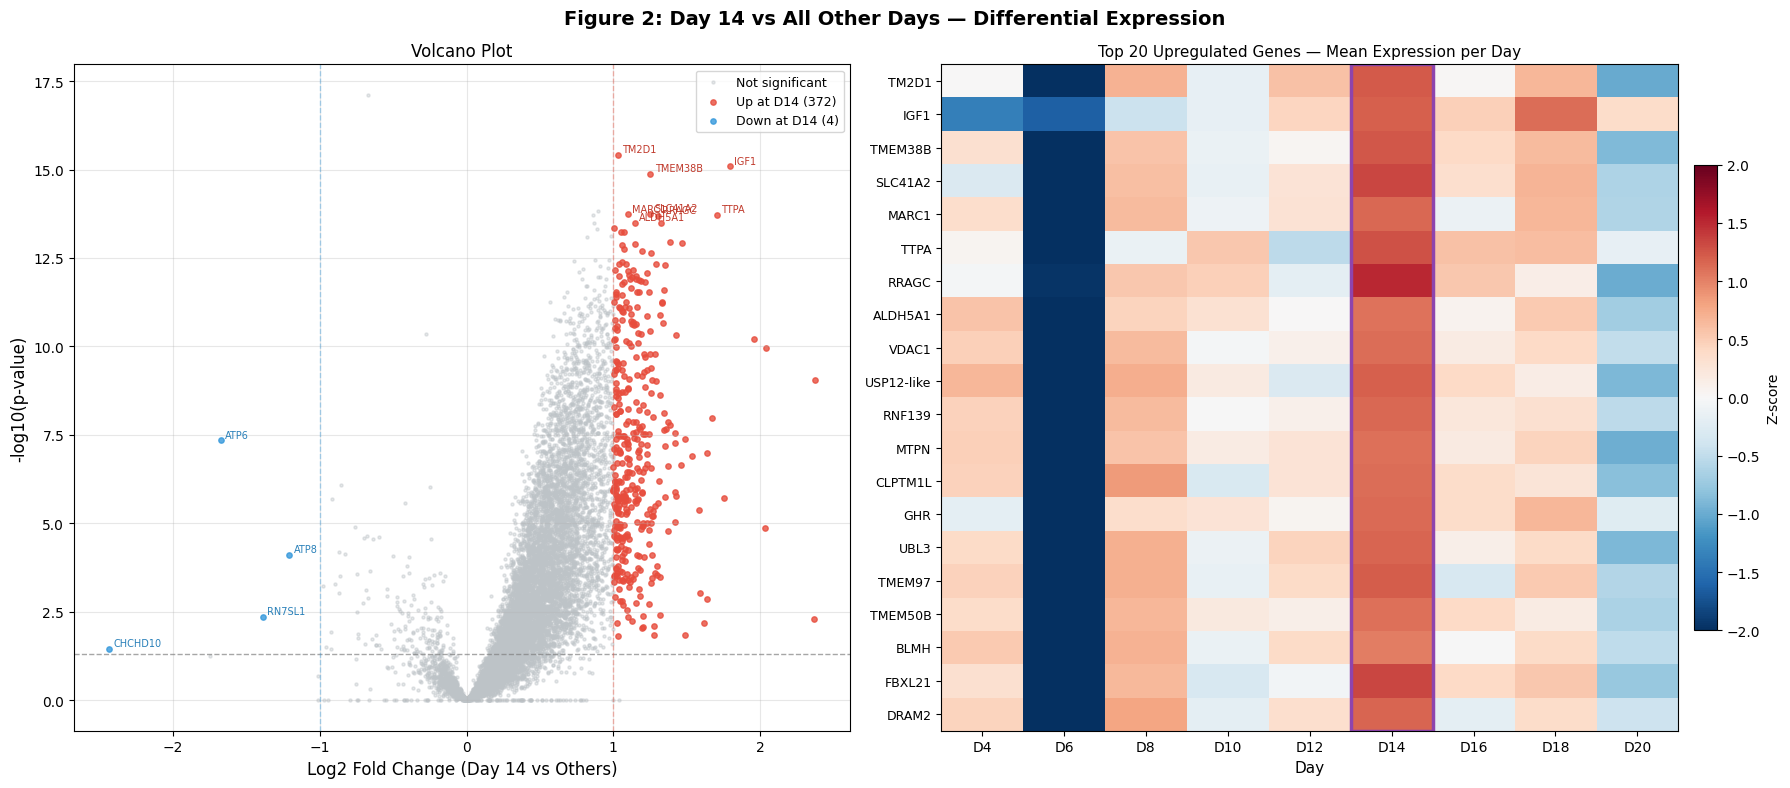

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Figure 2: Day 14 vs All Other Days — Differential Expression',
             fontsize=14, fontweight='bold')

ax = axes[0]
ns = de_df[~de_df['sig']]
ax.scatter(ns['LFC'],  ns['-log10p'],  c='#bdc3c7', s=5,  alpha=0.4, label='Not significant')
ax.scatter(up['LFC'],  up['-log10p'],  c='#e74c3c', s=15, alpha=0.8, label=f'Up at D14 ({len(up)})')
ax.scatter(dn['LFC'],  dn['-log10p'],  c='#3498db', s=15, alpha=0.8, label=f'Down at D14 ({len(dn)})')
ax.axhline(-np.log10(0.05), color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline( 1, color='#e74c3c', linestyle='--', linewidth=1, alpha=0.4)
ax.axvline(-1, color='#3498db', linestyle='--', linewidth=1, alpha=0.4)
for _, row in up.nlargest(8, '-log10p').iterrows():
    ax.annotate(row['Gene'], (row['LFC'], row['-log10p']),
                fontsize=7, color='#c0392b', xytext=(3, 2), textcoords='offset points')
for _, row in dn.nlargest(4, '-log10p').iterrows():
    ax.annotate(row['Gene'], (row['LFC'], row['-log10p']),
                fontsize=7, color='#2980b9', xytext=(3, 2), textcoords='offset points')
ax.set_xlabel('Log2 Fold Change (Day 14 vs Others)', fontsize=12)
ax.set_ylabel('-log10(p-value)', fontsize=12)
ax.set_title('Volcano Plot', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# This averages per day so patterns are immediately readable
ax2 = axes[1]

# Top 20 upregulated genes only (cleaner story)
top_genes = [g for g in up.nlargest(20, '-log10p')['Gene'].tolist()
             if g in log_expr.index]

# Compute per-day mean for each gene
day_means = {}
for day in DAYS:
    cols = sample_meta[sample_meta['Day'] == day]['Sample'].tolist()
    day_means[day] = log_expr.loc[top_genes, cols].mean(axis=1)

heat_data = pd.DataFrame(day_means, index=top_genes)   # genes × days

# Z-score across days so each gene is on same scale
heat_z = heat_data.subtract(heat_data.mean(axis=1), axis=0) \
                  .divide(heat_data.std(axis=1) + 1e-9, axis=0)

im = ax2.imshow(heat_z.values, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)

ax2.set_yticks(range(len(top_genes)))
ax2.set_yticklabels(top_genes, fontsize=9)
ax2.set_xticks(range(len(DAYS)))
ax2.set_xticklabels([f'D{d}' for d in DAYS], fontsize=10)   # ← day labels on x-axis
ax2.set_title('Top 20 Upregulated Genes — Mean Expression per Day', fontsize=11)
ax2.set_xlabel('Day', fontsize=11)

# Highlight Day 14 column with purple box
d14_col = DAYS.index(14)
ax2.add_patch(plt.Rectangle(
    (d14_col - 0.5, -0.5), 1, len(top_genes),
    linewidth=2.5, edgecolor='#8e44ad', facecolor='none'
))

plt.colorbar(im, ax=ax2, fraction=0.03, pad=0.02, label='Z-score')
plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, 'fig2_day14_DE.png'), dpi=150, bbox_inches='tight')
plt.show()



Finding genes that peak at Day 14...
  Genes peaking at Day 14 : 2,860 out of 10,515
  Top 6 peak genes        : ['ELOVL2', 'GGH', 'IGF1', 'PSAP', 'UQCRFS1', 'AQP9']


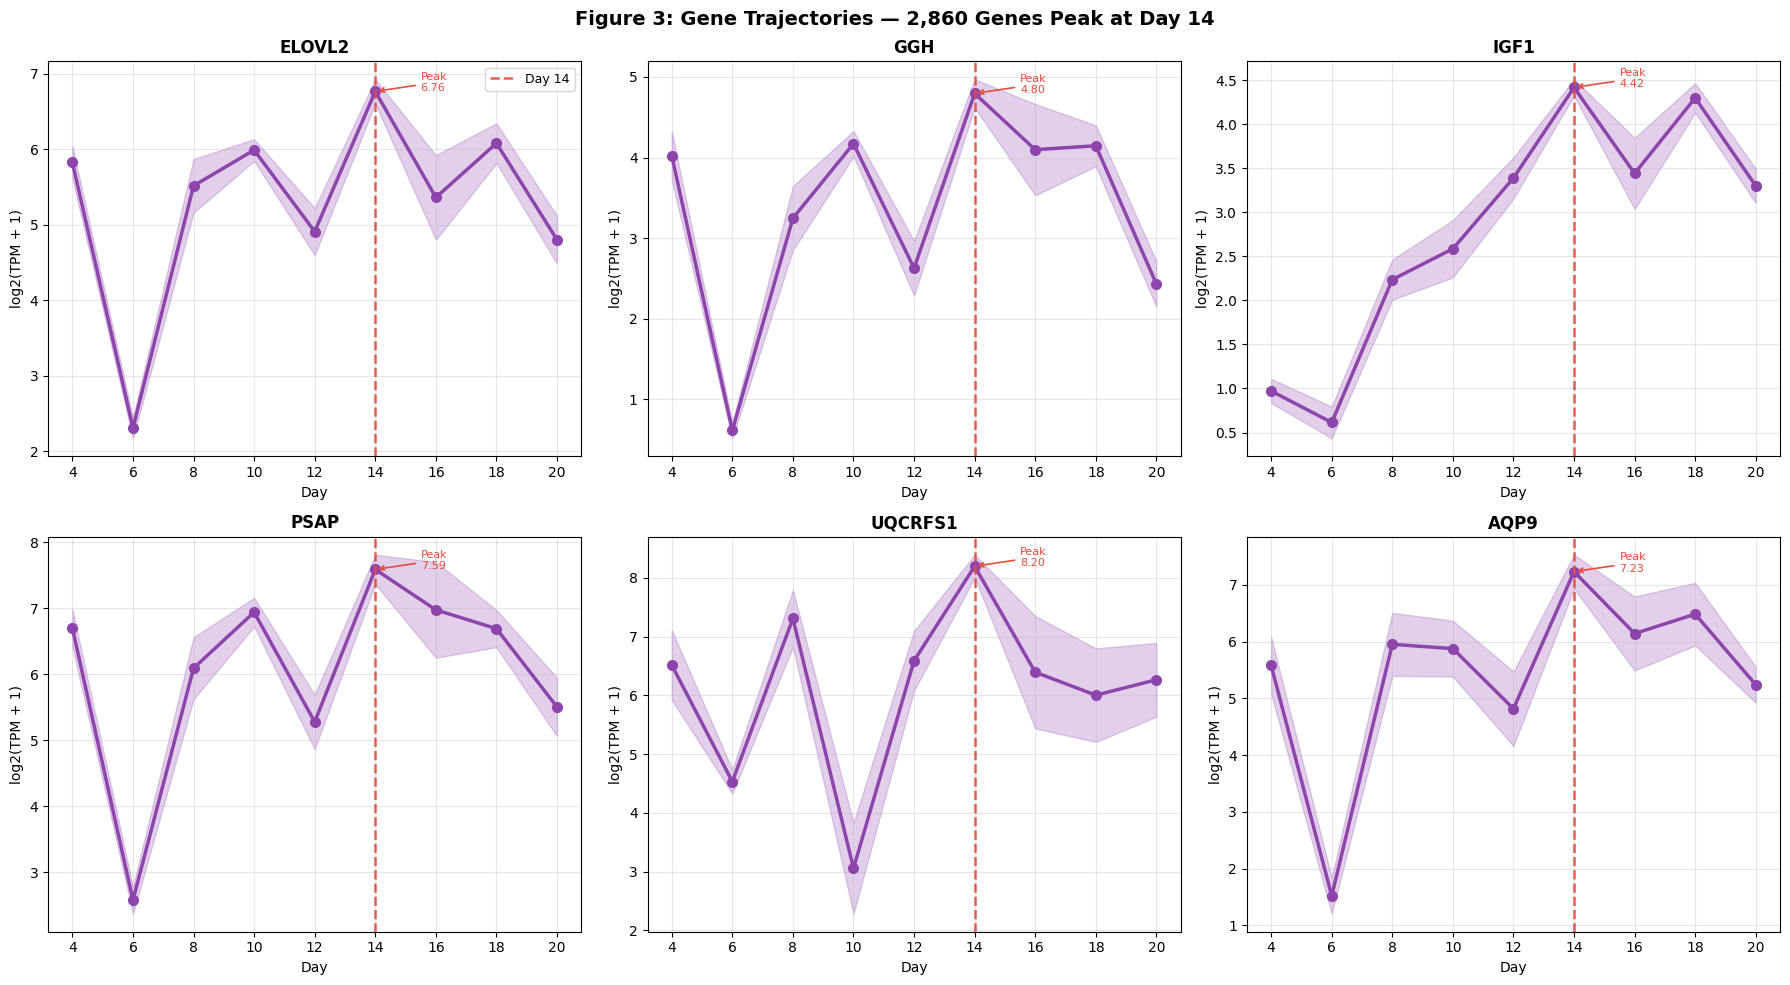

In [43]:
print("Finding genes that peak at Day 14...")

day_mean_arr = {}
day_sem_arr  = {}
for day in DAYS:
    cols = sample_meta[sample_meta['Day'] == day]['Sample'].tolist()
    day_mean_arr[day] = log_expr[cols].mean(axis=1).values.astype(float)
    day_sem_arr[day]  = log_expr[cols].sem(axis=1).values.astype(float)

traj_arr   = np.column_stack([day_mean_arr[d] for d in DAYS])   # genes × days
gene_names = list(log_expr.index)

d14_col_idx  = DAYS.index(14)
gene_max_col = traj_arr.argmax(axis=1)
above_mean   = traj_arr[:, d14_col_idx] > traj_arr.mean(axis=1) + 0.5
peak14_mask  = (gene_max_col == d14_col_idx) & above_mean
n_peak       = peak14_mask.sum()

print(f"  Genes peaking at Day 14 : {n_peak:,} out of {len(gene_names):,}")

# Top 6 by variance — these have the clearest mountain shape
peak14_idx   = np.where(peak14_mask)[0]
named_mask   = np.array([not (gene_names[i].startswith('-') or
                              gene_names[i].startswith('ENSGAL'))
                         for i in peak14_idx])
named_idx    = peak14_idx[named_mask]
top6_by_var  = named_idx[np.argsort(traj_arr[named_idx].var(axis=1))[-6:]]
peak14_genes = [gene_names[i] for i in top6_by_var]
print(f"  Top 6 peak genes        : {peak14_genes}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Figure 3: Gene Trajectories — {n_peak:,} Genes Peak at Day 14',
             fontsize=14, fontweight='bold')

for i, gene in enumerate(peak14_genes):
    ax   = axes[i // 3][i % 3]
    gi   = gene_names.index(gene)
    vals = traj_arr[gi]
    sems = np.array([day_sem_arr[d][gi] for d in DAYS])

    ax.fill_between(DAYS, vals - sems, vals + sems, alpha=0.25, color='#8e44ad')
    ax.plot(DAYS, vals, 'o-', color='#8e44ad', linewidth=2.5, markersize=7)
    ax.axvline(14, color='#e74c3c', linestyle='--', linewidth=1.8, alpha=0.9, label='Day 14')

    peak_y = vals[d14_col_idx]
    ax.annotate(f'Peak\n{peak_y:.2f}',
                xy=(14, peak_y), xytext=(15.5, peak_y),
                arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2),
                fontsize=8, color='#e74c3c')

    ax.set_title(gene, fontsize=12, fontweight='bold')
    ax.set_xlabel('Day', fontsize=10)
    ax.set_ylabel('log2(TPM + 1)', fontsize=10)
    ax.set_xticks(DAYS)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=9)

plt.tight_layout()

## New dataframe with values average over days

In [ ]:
# First make a dictionary with col name corresponding to days
groups = {}
for col in df.columns[3:]:
  day = col.split("_")[-1]
  # If day not in dict, intializes, otherwise append col to that list
  groups.setdefault(day, []).append(col)
print(len(groups["4"]), groups["4"])

df_days = pd.DataFrame()

11 ['1650_summed_TPM_4', '1651_summed_TPM_4', '1653_summed_TPM_4', '1654_summed_TPM_4', '1655_summed_TPM_4', '1656_summed_TPM_4', '1657_summed_TPM_4', '1671_summed_TPM_4', '1672_summed_TPM_4', '1673_summed_TPM_4', '1776_summed_TPM_4']


In [ ]:
# Add gene symbols as first column
df_days = pd.DataFrame({df.columns[0]: df.iloc[:,ind]})

# Find the mean and variance for days
for day, cols in groups.items():
  df_days[f"day{day}_avg"] = df[cols].mean(axis=1)
  df_days[f"day{day}_sigma"] = df[cols].var(axis=1)
df_days

,Gene Symbol,day4_avg,day4_sigma,day6_avg,day6_sigma,day8_avg,day8_sigma,day10_avg,day10_sigma,day12_avg,day12_sigma,day14_avg,day14_sigma,day16_avg,day16_sigma,day18_avg,day18_sigma,day20_avg,day20_sigma
0,ZZZ3,4.225709,2.517081,0.953764,0.236265,4.278279,2.169685,4.195737,3.731420,3.034347,1.728714,5.011790,0.892738,5.130389,9.468639,3.784953,1.347033,2.150913,1.377910
1,ZYX,36.047936,128.615525,19.705650,50.019128,29.822050,29.563380,30.575958,70.740881,29.802075,40.237388,30.175145,37.592915,32.275750,232.706551,25.898283,62.448888,27.205017,74.934826
2,ZXDC,2.607343,0.948288,0.777705,0.099151,2.712533,0.307017,2.360046,0.334795,2.362605,1.060999,2.876152,0.497583,2.983429,3.308391,2.311302,0.364755,1.841165,0.499996
3,ZW10,7.528290,5.357893,2.225634,0.790829,7.726521,2.562777,6.723687,4.861016,6.354158,6.124200,8.891599,3.149292,8.195503,21.528411,6.118378,2.442329,4.577793,3.223964
4,ZUFSP,2.978055,0.426497,1.061303,0.310436,4.806378,2.082001,3.969455,1.846055,3.463997,3.029641,5.564387,3.310879,5.995768,13.203438,5.555640,4.883451,2.157520,0.694160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14460,A4GALT,0.122044,0.006417,0.082118,0.001656,0.258182,0.009369,0.289407,0.027268,0.425451,0.016768,0.396496,0.014947,0.397687,0.056705,0.425251,0.048323,0.256623,0.032031
14461,A2ML4,551.419455,70636.710641,226.178283,13908.780751,594.449333,77057.541869,759.427500,56240.779358,513.685917,36339.196924,819.509727,64960.204381,1024.191250,560689.746632,720.742750,48419.017177,766.655750,93687.188298
14462,A2ML2,196.006000,2076.804730,77.918633,2032.221987,190.413658,2479.902551,207.086750,2906.735239,184.406167,3459.627833,297.231727,4893.783380,225.701117,13326.146568,298.123917,5467.390572,225.626392,9473.869084
14463,A1CF,68.160064,1235.826170,10.178156,6.156964,39.292748,800.760427,82.992950,456.928781,37.565825,1060.531148,72.911318,557.412911,62.248866,829.201585,67.366875,1217.030397,33.796170,428.364901


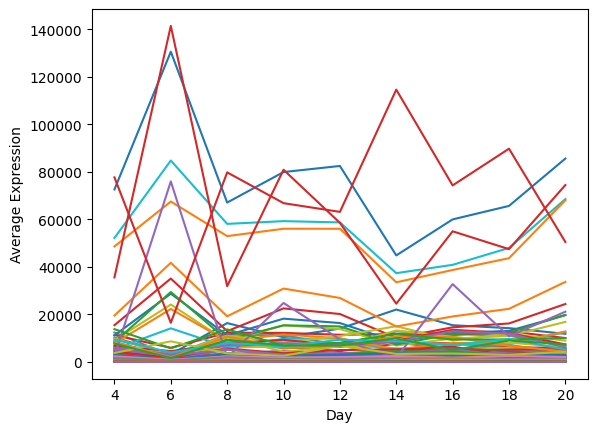

In [ ]:
import matplotlib.pyplot as plt

#iterating over the rows or essentially genes
for _, row in df_days.iterrows():
  x = []
  y = []
  for day, cols in groups.items():
    x.append(int(day))
    y.append(row[f"day{day}_avg"])
  plt.plot(x,y)
  plt.xlabel("Day")
  plt.ylabel("Average Expression")
  #plt.yscale('log')

In [ ]:
#col_new_names = [name.split('_')[0] +'_' +name.split('_')[3] for name in df.columns[1:]]
#col_new_names[:5]
#df.columns = list(df.columns[:1]) + col_new_names
#df

In [ ]:
chicken_tag = [tag_name.split('_')[0] for tag_name in df.columns[2:]]
list_days = list(set([int(day.split('_')[-1]) for day in df.columns[2:]]))

In [ ]:
list_days.sort()
list_days

[4, 6, 8, 10, 12, 14, 16, 18, 20]

In [ ]:
df_day4 = df.loc[:,["Gene Symbol"] + df.filter(regex=r"_4$").columns.tolist()]

In [ ]:
df_day4

,Gene Symbol,1650_summed_TPM_4,1651_summed_TPM_4,1653_summed_TPM_4,1654_summed_TPM_4,1655_summed_TPM_4,1656_summed_TPM_4,1657_summed_TPM_4,1671_summed_TPM_4,1672_summed_TPM_4,1673_summed_TPM_4,1776_summed_TPM_4
0,ZZZ3,2.148670,4.204060,3.609380,6.677230,3.849120,7.354150,5.040800,3.031530,2.721210,3.941250,3.905400
1,ZYX,24.366200,32.569200,31.253900,37.847200,37.692800,56.604800,33.385700,27.918300,34.052300,57.311000,23.525900
2,ZXDC,2.032480,2.471470,1.543100,3.037720,1.771860,4.079810,2.900180,2.161720,2.230180,4.596810,1.855440
3,ZW10,4.834760,7.150830,5.563670,10.117100,5.905610,12.052000,9.869820,6.426870,5.543910,8.634280,6.712340
4,ZUFSP,3.170700,2.908370,2.354820,3.346660,2.564770,3.133150,4.454180,3.496990,2.421560,2.140630,2.766770
...,...,...,...,...,...,...,...,...,...,...,...,...
14460,A4GALT,0.074452,0.156464,0.029587,0.139465,0.190539,0.308782,0.056601,0.067055,0.061017,0.105077,0.153445
14461,A2ML4,243.909000,340.262000,289.809000,584.728000,281.682000,509.980000,664.186000,492.456000,1092.230000,723.640000,842.732000
14462,A2ML2,247.332000,182.951000,172.501000,183.129000,118.826000,234.194000,283.293000,169.966000,165.030000,182.840000,216.004000
14463,A1CF,22.040600,55.038200,26.661900,96.158400,26.078800,69.539400,111.482000,104.168000,76.200500,114.381000,48.011900


In [ ]:
#df_day6 = df.loc[:,["Gene Symbol"] + df.filter(regex=r"_6$").columns.tolist()]
#df_day6

In [ ]:
#df